# Regression Modeling of the Vinho Verde Dataset

**Context**

This notebook is the second step of our study on the "Vinho Verde" dataset. Building on our exploratory analysis, we aim to develop regression models to predict the numerical quality of wines based on their physicochemical properties. This step is crucial for understanding how different factors quantitatively influence wine quality.

**Objectives of this Notebook**
1. Define feature matrix \( X \) and target vector \( y \), which is modeled by a belonging rate to the set of "good wines", or by a binary variable
2. Establish a modeling pipeline with scaling, optional dimensionality reduction (PCA), and regression models.
3. Use cross-validation to compare models via RMSE, \( R^2 \), and residual diagnostics.
4. Analyze and interpret the regression results to understand key drivers of wine quality.

**Notebook Outline**
1. **Data Preparation**
2. **Model Training, Validation and Comparaison**
3. **Residual Analysis**
4. **Model Training, Validation and Comparaison with PCA**
5. **Logistic Regression**

## 1. Data Preparation

In [2]:
# Imports
from __future__ import annotations

import os
import sys
from typing import Dict, Any, TypedDict, List, Final
from collections import Counter
from scipy.stats import randint

from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix, accuracy_score
from sklearn.svm import SVR

def split_dataset(
    df: pd.DataFrame,
    feature_cols: List[str],
    target_col: str,
    test_size: float = 0.2,
    random_state: int = 42
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """
    Split features and target into train/test sets.

    Parameters:
        df (pd.DataFrame): Full dataset.
        feature_cols (List[str]): Names of feature columns.
        target_col (str): Name of target column.
        test_size (float): Proportion for test set.
        random_state (int): Seed for reproducibility.

    Returns:
        Tuple containing X_train, X_test, y_train, y_test.
    """
    X: pd.DataFrame = df[feature_cols]
    y: pd.Series = df[target_col] * 0.1  # Modeling a rate of belonging to the set of good wines
    return train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

# Load the processed dataset
path: str = os.path.join(os.path.dirname(os.getcwd()), "data", "wine_quality_processed.csv")
df: pd.DataFrame = pd.read_csv(path)

# Select feature columns (continuous features defined earlier)
feature_cols: List[str] = [
    "fixed_acidity", "volatile_acidity", "citric_acid",
    "residual_sugar", "chlorides", "free_sulfur_dioxide",
    "total_sulfur_dioxide", "density", "ph", "sulphates", "alcohol"
]

X: pd.DataFrame = df[feature_cols]
y: pd.Series = df["quality"] * 0.1

# Perform split
X_train, X_test, y_train, y_test = split_dataset(
    df, feature_cols, "quality", test_size=0.2
)

# Apply PCA for dimensionality reduction
pca = PCA(n_components=0.9)  # Retain 90% of the variance
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

pca_train_df = pd.DataFrame(data=X_train_pca, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7'])
pca_train_df['quality'] = y_train.values

pca_test_df = pd.DataFrame(data=X_test_pca, columns=['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7'])
pca_test_df['quality'] = y_test.values

## 2. Model Training, Validation and Comparaison

In [3]:
# Define the models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Polynomial Regression': make_pipeline(PolynomialFeatures(degree=2), Ridge()),
    'Support Vector Regression': SVR(kernel='rbf', C=1.0, epsilon=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
}

# Train and evaluate each model
for name, model in models.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.95)),
        ('model', model)
    ])

    scores = cross_val_score(pipeline, X, y, cv=5, scoring='neg_mean_squared_error')
    rmse_scores = (-scores)**0.5
    print(f'{name} - Average RMSE: {rmse_scores.mean():.2f}')

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    print(f'{name} - R^2: {r2:.2f}')

Linear Regression - Average RMSE: 0.07
Linear Regression - R^2: 0.39
Ridge Regression - Average RMSE: 0.07
Ridge Regression - R^2: 0.39
Polynomial Regression - Average RMSE: 0.07
Polynomial Regression - R^2: 0.30
Support Vector Regression - Average RMSE: 0.07
Support Vector Regression - R^2: 0.26
Random Forest - Average RMSE: 0.07
Random Forest - R^2: 0.43
Gradient Boosting - Average RMSE: 0.07
Gradient Boosting - R^2: 0.37


## 3. Residuals Analysis

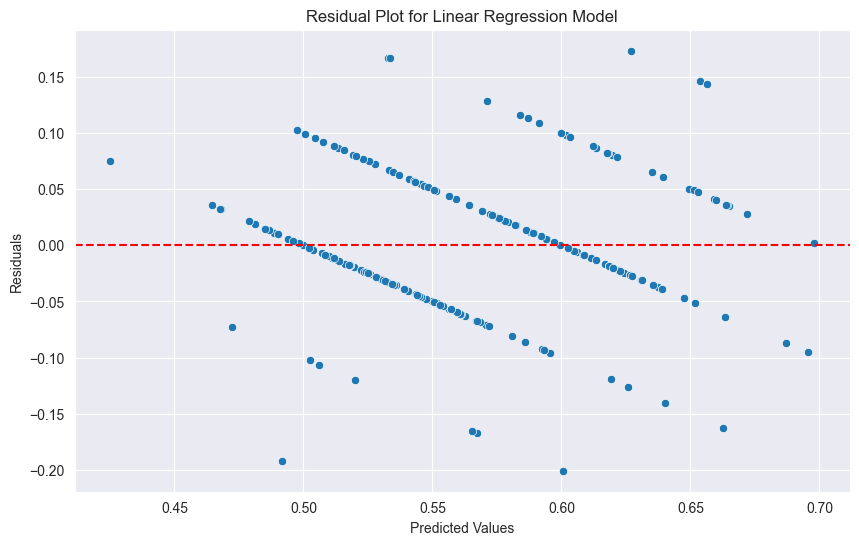

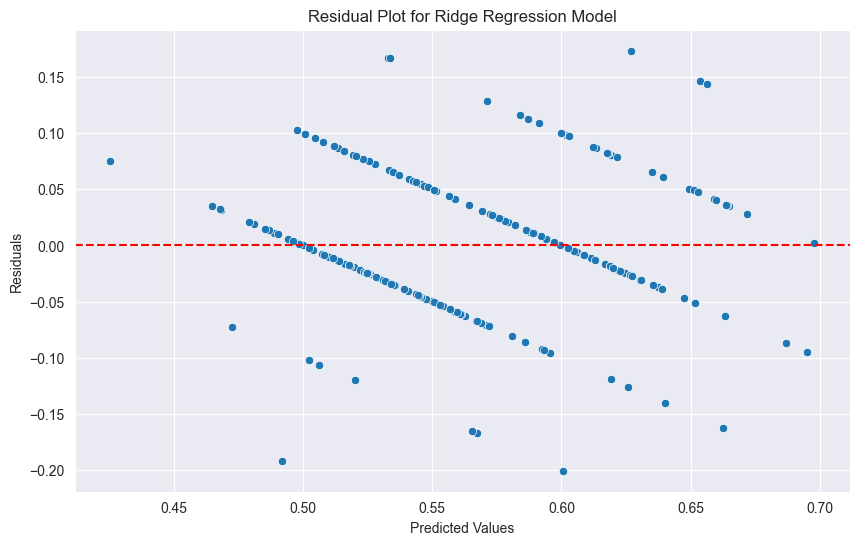

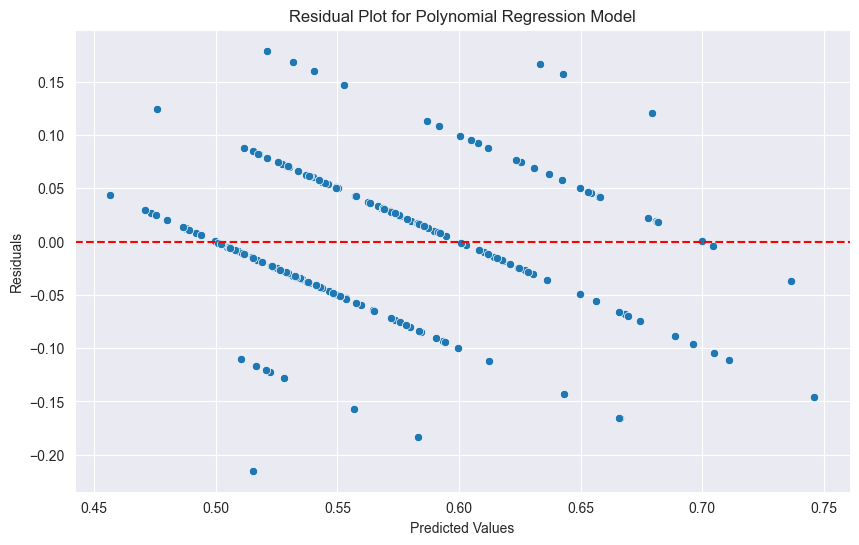

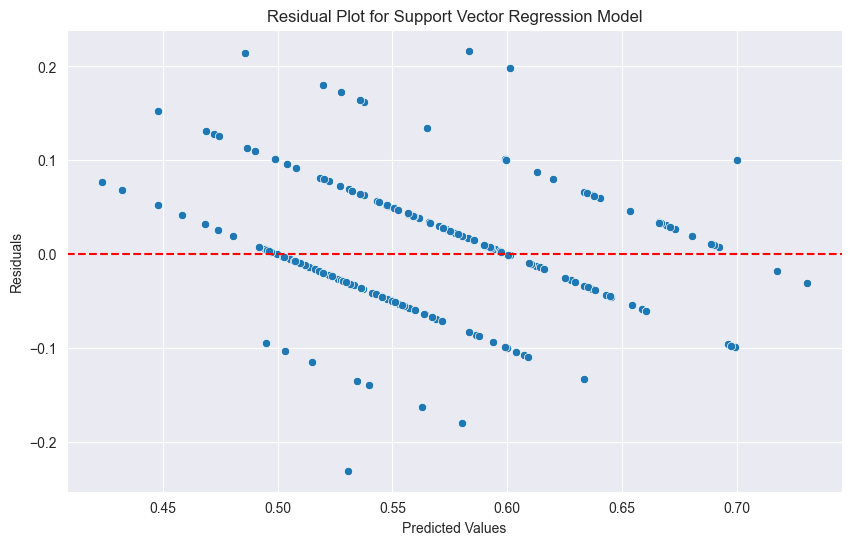

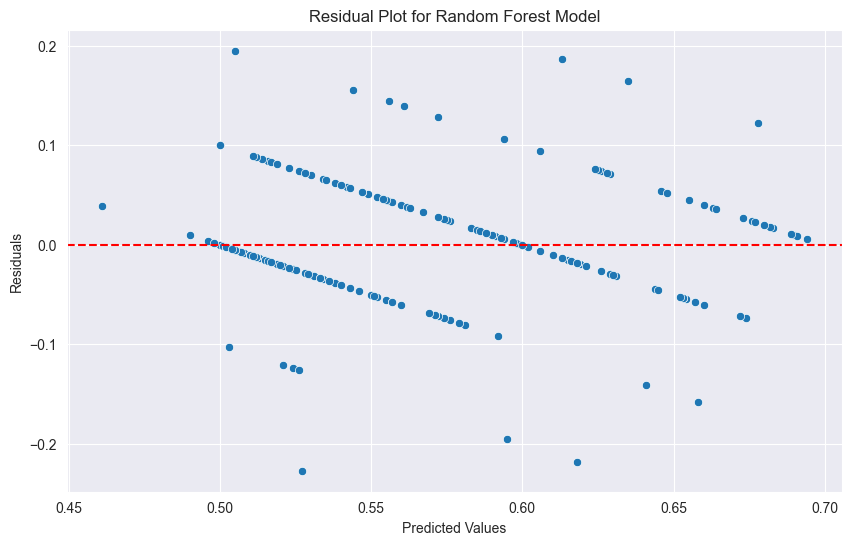

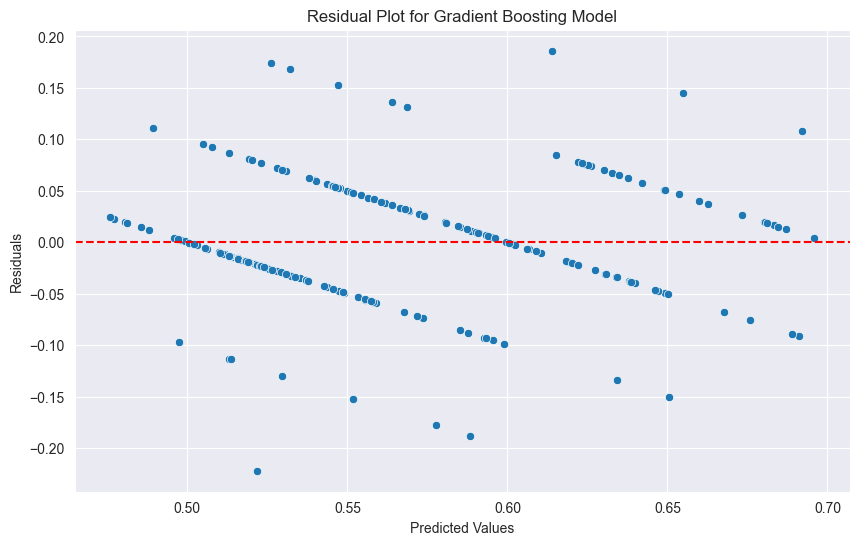

In [4]:
# Plot residuals for the three models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    residuals = y_test - y_pred

    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_pred, y=residuals)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.title(f'Residual Plot for {name} Model')
    plt.show()

## 4 - Model Training, Validation and Comparaison with PCA

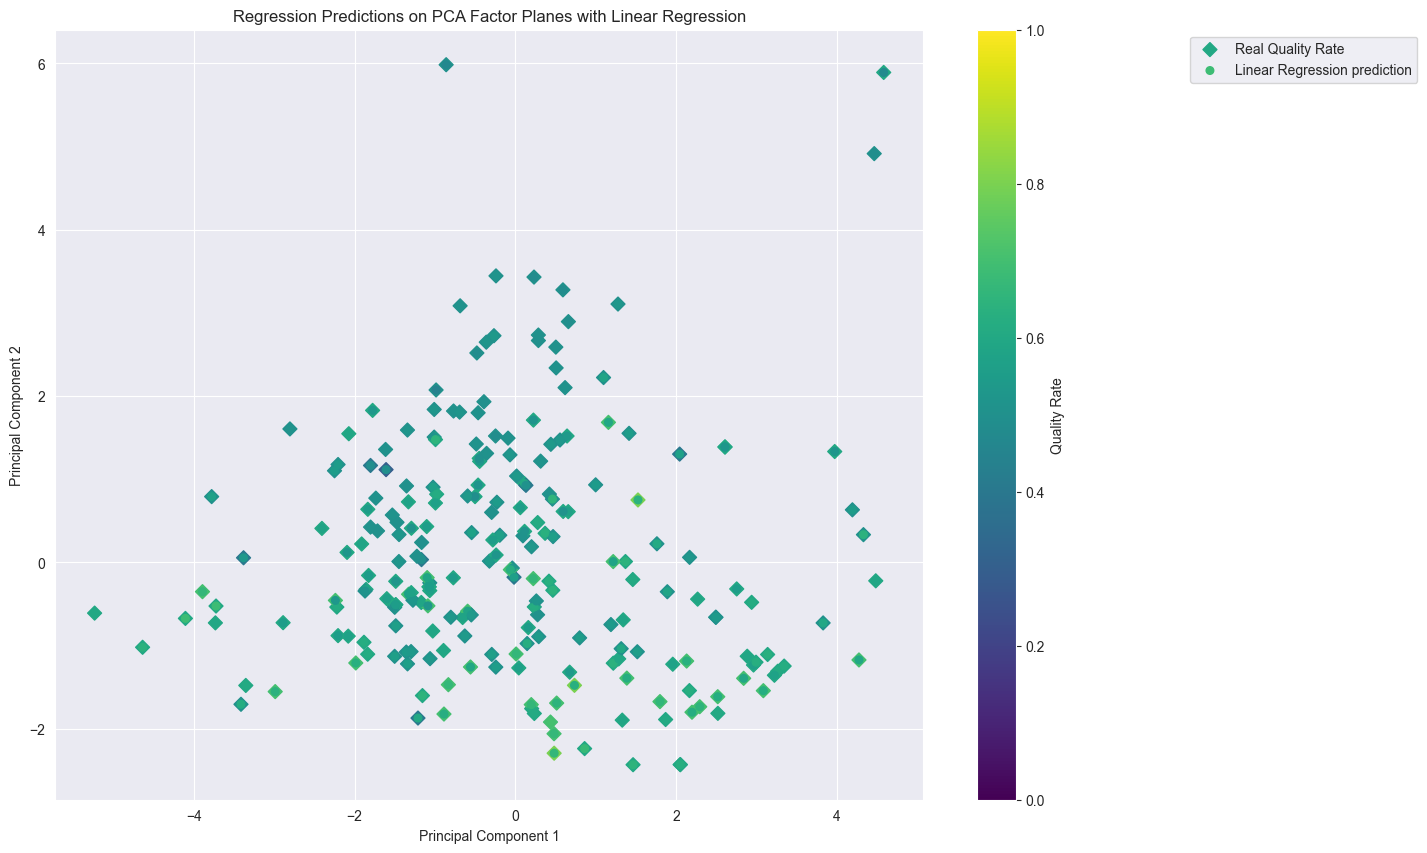

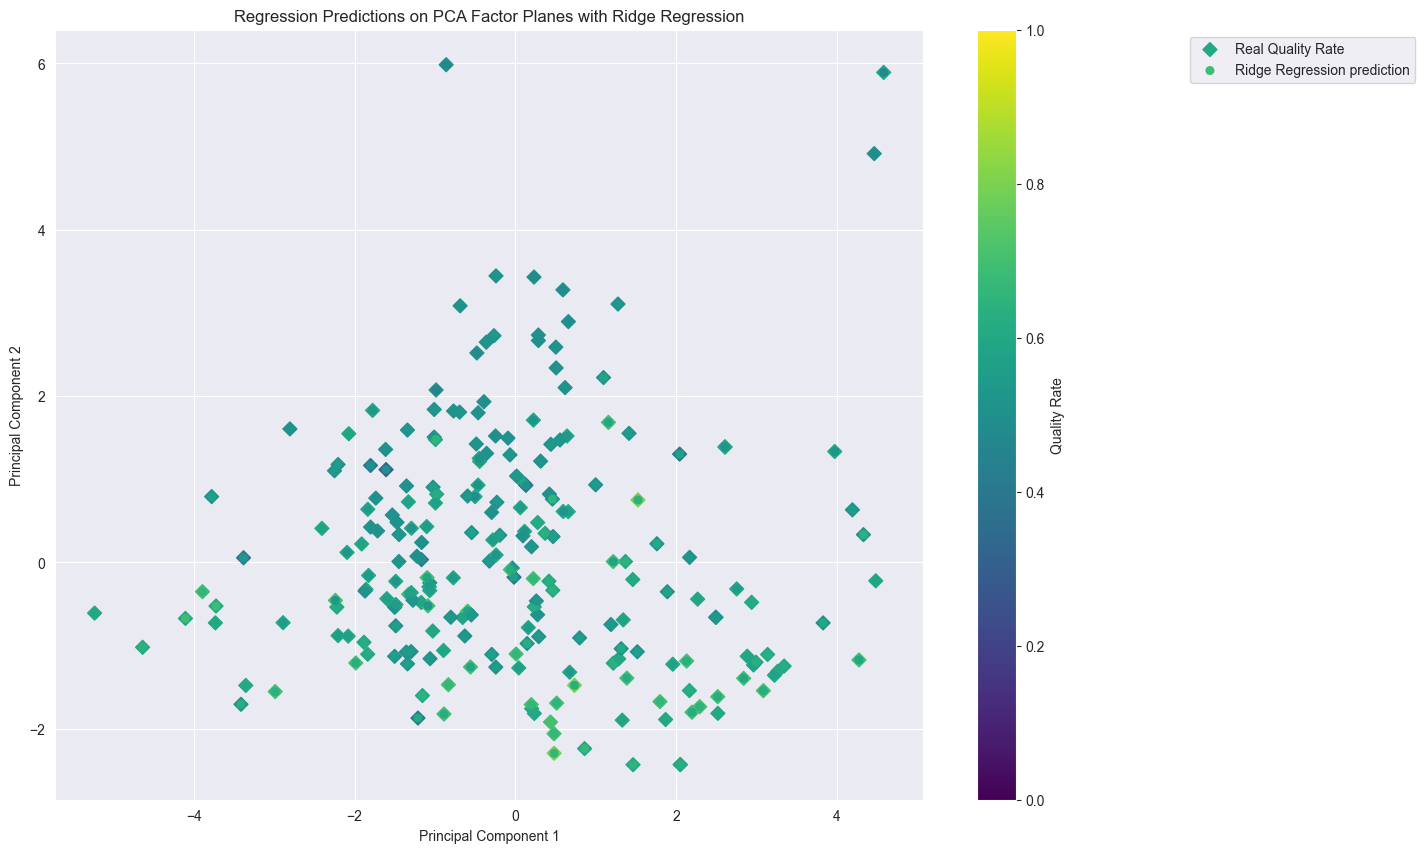

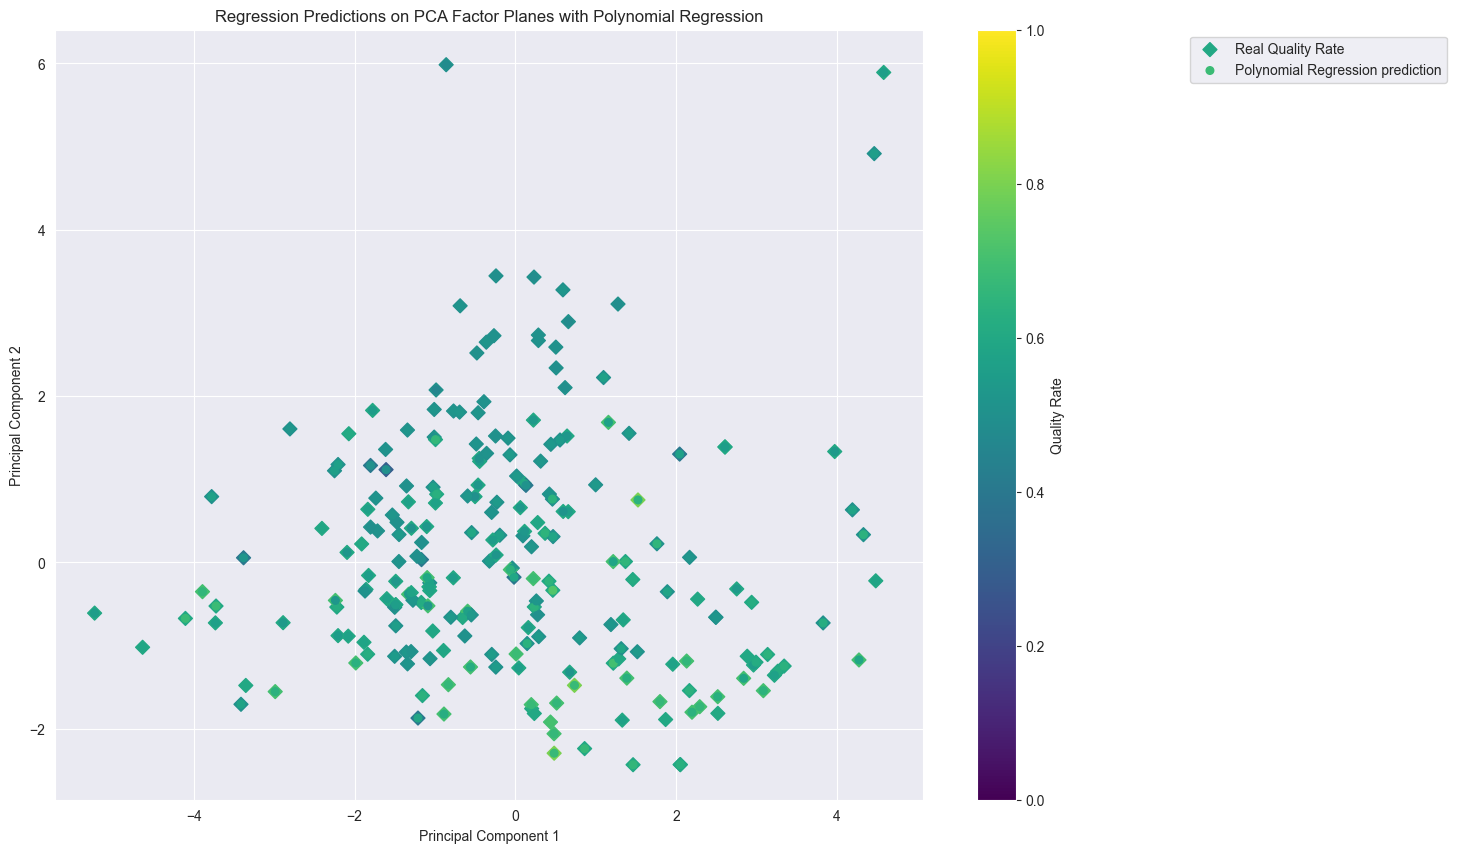

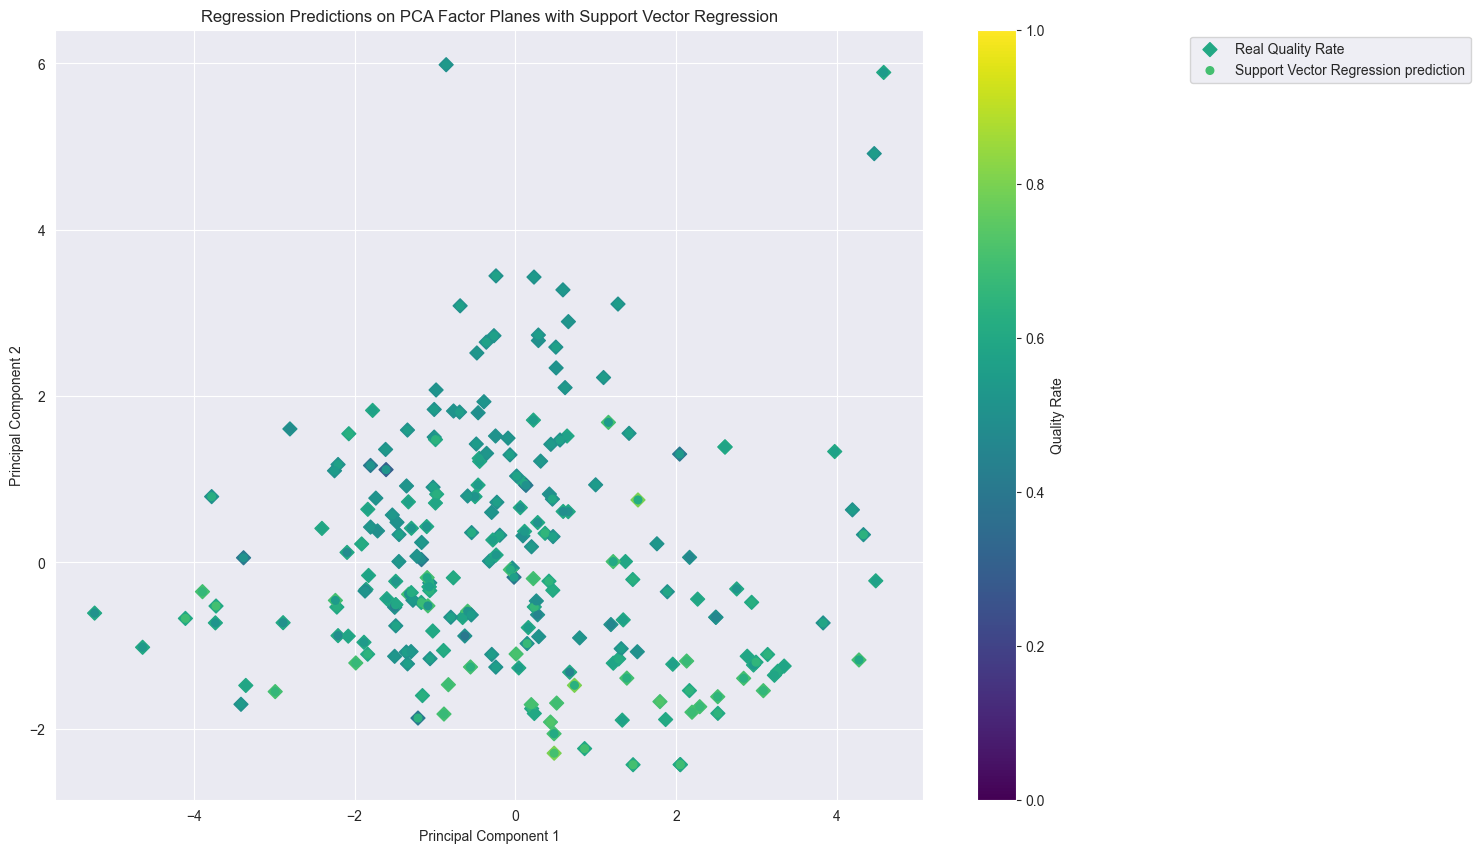

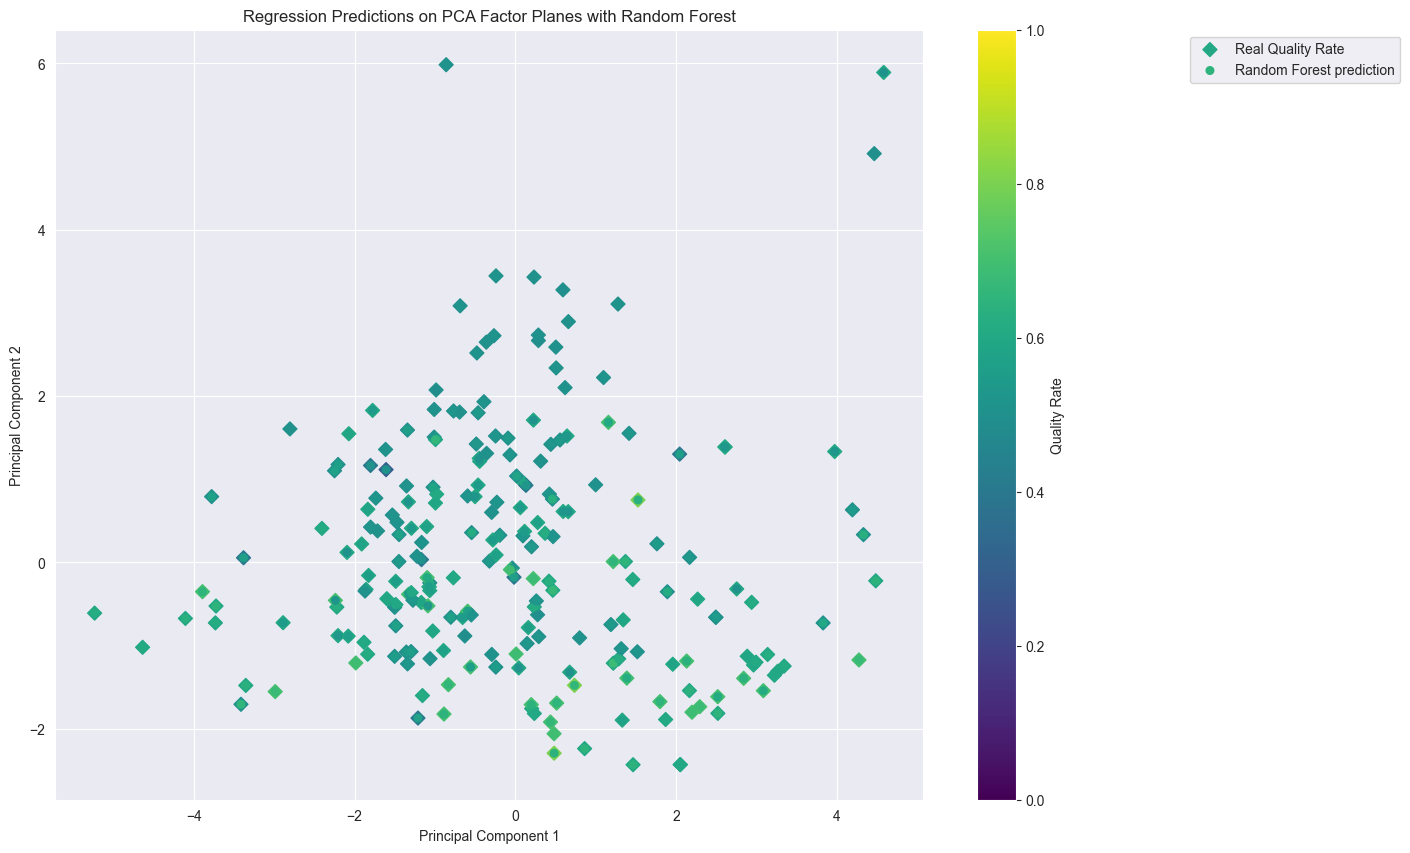

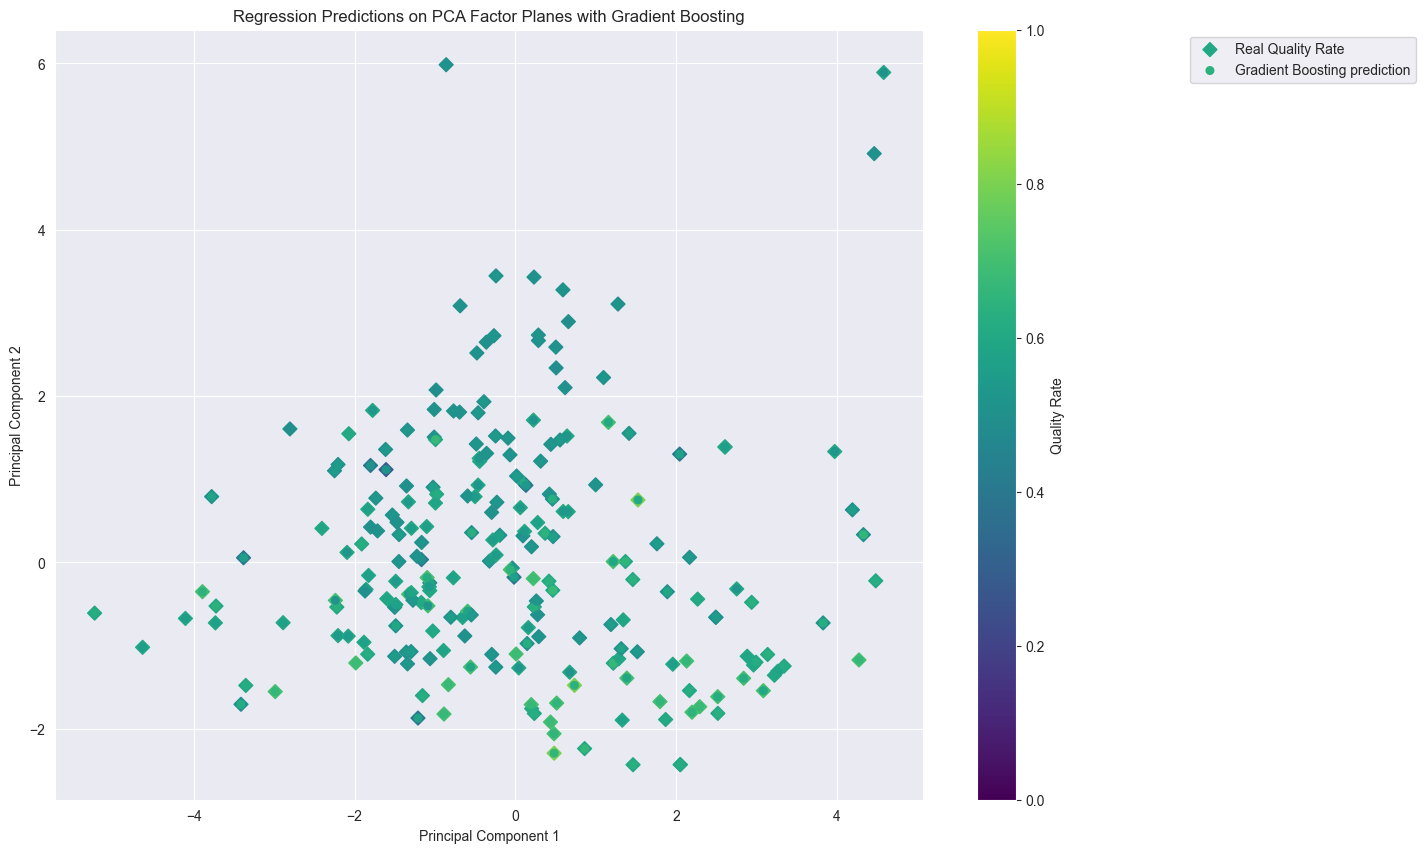

In [5]:
for name, model in models.items():
    model.fit(X_train_pca, y_train)
    pca_test_df[f'{name} prediction'] = model.predict(X_test_pca)

    # Tracer les résultats des régressions sur le plan factoriel de l'ACP
    plt.figure(figsize=(14, 10))

    # Tracer les points réels
    scatter_real = plt.scatter(pca_test_df['PC1'], pca_test_df['PC2'], c=pca_test_df['quality'], cmap='viridis', marker='D', s=50, vmin=0, vmax=1, alpha=1, label='Real Quality Rate')

    # Tracer les prédictions des modèles
    plt.scatter(pca_test_df['PC1'], pca_test_df['PC2'], c=pca_test_df[f'{name} prediction'], cmap='viridis', marker='o', s=30, vmin=0, vmax=1, alpha=1, label=f'{name} prediction')

    # Ajouter une barre de couleur pour la légende
    cbar = plt.colorbar(scatter_real)
    cbar.set_label('Quality Rate')

    plt.title(f'Regression Predictions on PCA Factor Planes with {name}')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend(loc='upper left', bbox_to_anchor=(1.3, 1))
    plt.show()

## 5. Logistic Regression

Accuracy: 0.6637554585152838

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.59      0.62       105
           1       0.68      0.73      0.70       124

    accuracy                           0.66       229
   macro avg       0.66      0.66      0.66       229
weighted avg       0.66      0.66      0.66       229


Confusion Matrix:
 [[62 43]
 [34 90]]
  Feature  Importance
0     PC1    0.029701
1     PC2   -0.749002


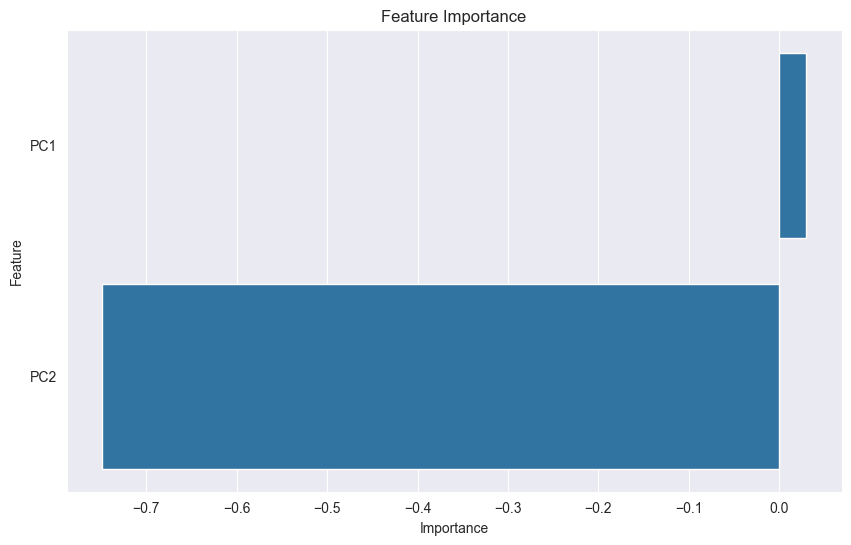

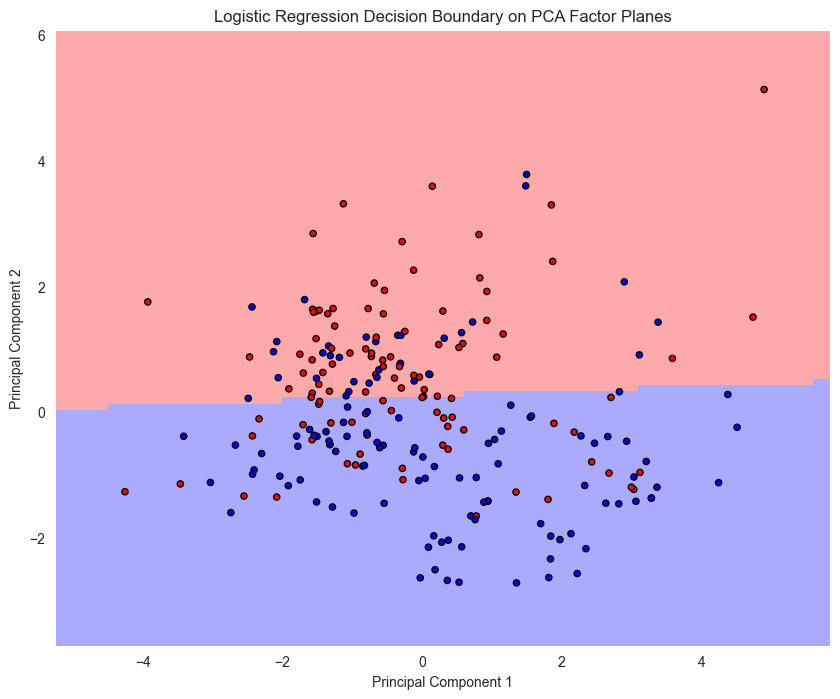

In [10]:
def split_bin_dataset(
    df: pd.DataFrame,
    feature_cols: List[str],
    target_col: str,
    test_size: float = 0.2,
    random_state: int = 42
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """
    Split features and target into train/test sets.

    Parameters:
        df (pd.DataFrame): Full dataset.
        feature_cols (List[str]): Names of feature columns.
        target_col (str): Name of target column.
        test_size (float): Proportion for test set.
        random_state (int): Seed for reproducibility.

    Returns:
        Tuple containing X_train, X_test, y_train, y_test.
    """
    X: pd.DataFrame = df[feature_cols]
    y: pd.Series = (df[target_col] >= 6).astype(int)
    return train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

# Select feature columns (continuous features defined earlier)
feature_cols: List[str] = [
    "fixed_acidity", "volatile_acidity", "citric_acid",
    "residual_sugar", "chlorides", "free_sulfur_dioxide",
    "total_sulfur_dioxide", "density", "ph", "sulphates", "alcohol"
]

X_bin: pd.DataFrame = df[feature_cols]
y_bin: pd.Series = (df["quality"] >= 6).astype(int)

# Perform split
X_train_bin, X_test_bin, y_train_bin, y_test_bin = split_bin_dataset(
    df, feature_cols, "quality", test_size=0.2
)

pca2 = PCA(n_components=2)
# Apply PCA for dimensionality reduction
X_train_pca_bin = pca2.fit_transform(X_train_bin)
X_test_pca_bin = pca2.transform(X_test_bin)

pca_train_df_bin = pd.DataFrame(data=X_train_pca_bin, columns=['PC1', 'PC2'])
pca_train_df_bin['quality'] = y_train_bin.values

pca_test_df_bin = pd.DataFrame(data=X_test_pca_bin, columns=['PC1', 'PC2'])
pca_test_df_bin['quality'] = y_test_bin.values

# Initialiser et entraîner le modèle de régression logistique
logreg = LogisticRegression()
logreg.fit(X_train_pca_bin, y_train_bin)

# Prédire les valeurs pour l'ensemble de test
y_pred_bin = logreg.predict(X_test_pca_bin)

# Évaluer le modèle
print("Accuracy:", accuracy_score(y_test_bin, y_pred_bin))
print("\nClassification Report:\n", classification_report(y_test_bin, y_pred_bin))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_bin, y_pred_bin))

# Importance des caractéristiques
feature_importance = pd.DataFrame({'Feature': ['PC1', 'PC2'], 'Importance': logreg.coef_[0]})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print(feature_importance)

# Visualisation de l'importance des caractéristiques
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance')
plt.show()

# Créer une grille de points pour tracer la frontière de décision
x_min, x_max = X_test_pca_bin[:, 0].min() - 1, X_test_pca_bin[:, 0].max() + 1
y_min, y_max = X_test_pca_bin[:, 1].min() - 1, X_test_pca_bin[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

# Prédire les classes pour chaque point de la grille
Z = logreg.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Tracer la frontière de décision
plt.figure(figsize=(10, 8))
cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#0000FF'])

plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

# Tracer les points de test
plt.scatter(X_test_pca_bin[:, 0], X_test_pca_bin[:, 1], c=y_test_bin, cmap=cmap_bold, edgecolors='k', s=20)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.title("Logistic Regression Decision Boundary on PCA Factor Planes")
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.show()

Accuracy: 0.777292576419214

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.77      0.76       105
           1       0.80      0.78      0.79       124

    accuracy                           0.78       229
   macro avg       0.78      0.78      0.78       229
weighted avg       0.78      0.78      0.78       229


Confusion Matrix:
 [[81 24]
 [27 97]]
                 Feature  Importance
10               alcohol    1.025115
9              sulphates    0.472515
5    free_sulfur_dioxide    0.229790
0          fixed_acidity    0.203354
7                density    0.058995
8                     ph    0.028218
3         residual_sugar   -0.035858
4              chlorides   -0.102820
2            citric_acid   -0.291077
6   total_sulfur_dioxide   -0.563954
1       volatile_acidity   -0.604714


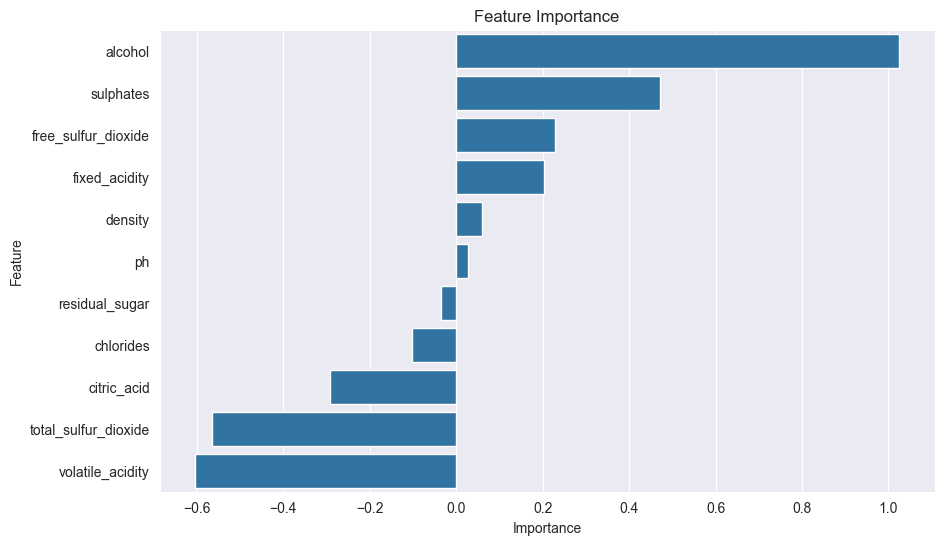

In [11]:
# Initialiser et entraîner le modèle de régression logistique
logreg = LogisticRegression()
logreg.fit(X_train_bin, y_train_bin)

# Prédire les valeurs pour l'ensemble de test
y_pred_bin = logreg.predict(X_test_bin)

# Évaluer le modèle
print("Accuracy:", accuracy_score(y_test_bin, y_pred_bin))
print("\nClassification Report:\n", classification_report(y_test_bin, y_pred_bin))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_bin, y_pred_bin))

# Importance des caractéristiques
feature_importance = pd.DataFrame({'Feature': feature_cols, 'Importance': logreg.coef_[0]})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print(feature_importance)

# Visualisation de l'importance des caractéristiques
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance')
plt.show()

## 6. Parameters amelioration

In [97]:
param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': randint(2, 10),
}

random_search = RandomizedSearchCV(estimator=RandomForestRegressor(random_state=42), param_distributions=param_dist, n_iter=10, cv=5)
random_search.fit(X_train, y_train)

best_params = random_search.best_params_
print(best_params)

{'max_depth': 20, 'min_samples_split': 6, 'n_estimators': 173}


In [100]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('model', RandomForestRegressor(max_depth=best_params['max_depth'], min_samples_split=best_params['min_samples_split'], n_estimators=best_params['n_estimators'], random_state=42))
])

scores = cross_val_score(pipeline, X, y, cv=5, scoring='neg_mean_squared_error')
rmse_scores = (-scores)**0.5
print(f'Average RMSE: {rmse_scores.mean():.2f}')

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f'R^2: {r2:.2f}')

Average RMSE: 0.07
R^2: 0.42
